# <p style="font-family:newtimeroman;font-size:150%;text-align:center;color:#8b4513;">The Severity Prediction of the Binary and Multi-Class Cardiovascular Disease: A Machine Learning-Based Fusion Approach </p>


***This is Six number Code for multi class fusion model-6 (RF+LR) using weighted score fusion***

In [648]:
# Import RandomForestClassifier for training a random forest model
from sklearn.ensemble import RandomForestClassifier
# Import train_test_split to split dataset into train and test sets
from sklearn.model_selection import train_test_split
# Import scaling utilities: MinMaxScaler and StandardScaler
from sklearn.preprocessing import MinMaxScaler,StandardScaler
# Import pyplot for plotting
from matplotlib import pyplot as plt
# Import numpy (alias and full) for numerical operations
import numpy
import numpy as np
# Import pandas for dataframe handling
import pandas as pd
# Import classification report utility
from sklearn.metrics import classification_report
# Import sklearn.metrics as a module for multiple metrics
import sklearn.metrics as metrics
# Import common metric helpers (accuracy, confusion matrix)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
# Ensure numpy alias is available (duplicate safe import)
import numpy as np

In [649]:
# Load the dataset from CSV into a pandas DataFrame
data = pd.read_csv('multiclassification.csv')
# Show first 10 rows to inspect the data
data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,class att
0,63,1,1,145,233,0,1,150,1,2.3,0,0,0,0
1,67,1,2,160,286,1,1,108,0,1.5,1,3,1,2
2,67,1,2,120,229,1,1,129,0,2.6,1,2,2,1
3,37,1,3,130,250,1,2,187,1,3.5,0,0,1,0
4,41,0,0,130,204,1,1,172,1,1.4,2,0,1,0
5,56,1,0,120,236,1,2,178,1,0.8,2,0,1,0
6,62,0,2,140,268,1,1,160,1,3.6,0,2,1,3
7,57,0,2,120,354,1,2,163,0,0.6,2,0,1,0
8,63,1,2,130,254,1,1,147,1,1.4,1,1,2,2
9,53,1,2,140,203,0,1,155,0,3.1,0,0,2,1


In [650]:
data.shape

(303, 14)

In [651]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    int64  
 1   sex        303 non-null    int64  
 2   cp         303 non-null    int64  
 3   trestbps   303 non-null    int64  
 4   chol       303 non-null    int64  
 5   fbs        303 non-null    int64  
 6    restecg   303 non-null    int64  
 7   thalach    303 non-null    int64  
 8   exang      303 non-null    int64  
 9   oldpeak    303 non-null    float64
 10  slope      303 non-null    int64  
 11  ca         303 non-null    int64  
 12  thal       303 non-null    int64  
 13  class att  303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [652]:
data.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
 restecg     0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
class att    0
dtype: int64

In [653]:
# Prepare feature matrix X and label vector y from DataFrame columns
x = data.iloc[:,0:13].values
y = data.iloc[:,13].values
# x contains columns 0..12, y is column 13

In [654]:
# Split dataset into training and testing sets (80:20 example)
# Note: the second split (70:30) will overwrite the first; uncomment the one you want
#for 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True)

#for 70:30 ratio
# X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, shuffle=True)
# Display training set shape
X_train.shape

(242, 13)

Class=0, n=135 (55.785%)
Class=3, n=29 (11.983%)
Class=1, n=40 (16.529%)
Class=2, n=27 (11.157%)
Class=4, n=11 (4.545%)


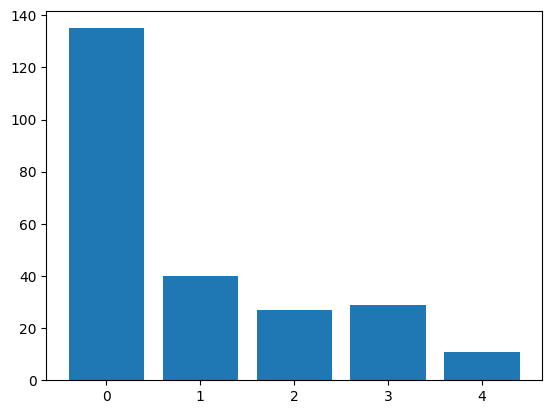

In [655]:
# Utilities for inspecting class distribution in training data
from pandas import read_csv
from collections import Counter
from matplotlib import pyplot
from sklearn.preprocessing import LabelEncoder

# summarize distribution
counter = Counter(y_train)
for k,v in counter.items():
	per = v / len(y_train) * 100
	print('Class=%d, n=%d (%.3f%%)' % (k, v, per))
# plot the class distribution as a bar chart
pyplot.bar(counter.keys(), counter.values())
pyplot.show()

The number of classes before fit Counter({np.int64(0): 135, np.int64(1): 40, np.int64(3): 29, np.int64(2): 27, np.int64(4): 11})
The number of classes after fit Counter({np.int64(0): 135, np.int64(3): 135, np.int64(1): 135, np.int64(2): 135, np.int64(4): 135})
Class=0, n=135 (20.000%)
Class=3, n=135 (20.000%)
Class=1, n=135 (20.000%)
Class=2, n=135 (20.000%)
Class=4, n=135 (20.000%)


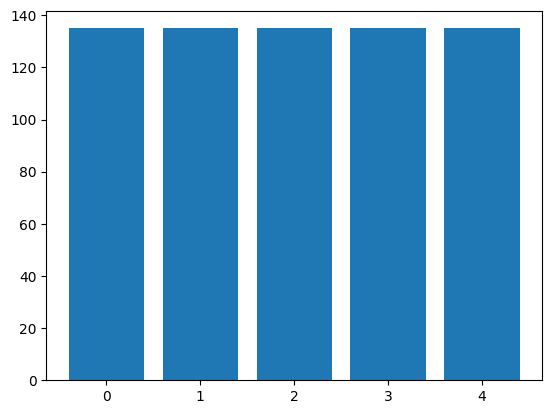

(675, 13)

In [656]:
"""##### Over Sampling"""

# Use RandomOverSampler to balance minority classes by oversampling
from imblearn.over_sampling import RandomOverSampler

os=RandomOverSampler()
X_train_ns,y_train_ns=os.fit_resample(X_train,y_train)
# Print counts before and after oversampling
print("The number of classes before fit {}".format(Counter(y_train)))
print("The number of classes after fit {}".format(Counter(y_train_ns)))

# summarize distribution
counter = Counter(y_train_ns)
for k,v in counter.items():
	per = v / len(y_train_ns) * 100
	print('Class=%d, n=%d (%.3f%%)' % (k, v, per))
# plot the re-balanced distribution
pyplot.bar(counter.keys(), counter.values())
pyplot.show()

# Replace training data with oversampled data
X_train=X_train_ns
y_train=y_train_ns

# Show new training shape
X_train.shape

In [657]:
# Initialize scalers: StandardScaler for z-score, MinMaxScaler for 0-1 scaling
# Used by different models to normalize features
sc = StandardScaler()

#min-max scaler for normalization for some algortihms
scaler = MinMaxScaler(feature_range=(0,1))

In [658]:
# code for Logistic Regression (LR) model training and evaluation
from sklearn.metrics import roc_auc_score  
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import precision_recall_fscore_support 

# Scale features for LR using StandardScaler
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# Initialize LR with regularization parameter C=0.1
model2 =LogisticRegression(C=.1)
           

# Fit LR on scaled training data
model2.fit(X_train_scaled,y_train)

# Get predicted class labels and class probabilities for test set
rounded_predictions2 = model2.predict(X_test_scaled)
predictions2 = model2.predict_proba(X_test_scaled)
y_pred2 = rounded_predictions2





Accuracy of LR =  0.639344262295082


In [676]:
import sklearn.metrics as metrics
# Compute and print LR accuracy
scores2=metrics.accuracy_score(y_test,y_pred2)
print("Accuracy of LR = ",scores2)
print(metrics.confusion_matrix(y_test,y_pred2))
print(metrics.classification_report(y_test,y_pred2))

Accuracy of LR =  0.639344262295082
[[27  1  2  0  0]
 [ 4  5  2  2  1]
 [ 1  1  3  0  4]
 [ 0  1  2  3  0]
 [ 0  1  0  0  1]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        30
           1       0.56      0.36      0.43        14
           2       0.33      0.33      0.33         9
           3       0.60      0.50      0.55         6
           4       0.17      0.50      0.25         2

    accuracy                           0.64        61
   macro avg       0.50      0.52      0.49        61
weighted avg       0.66      0.64      0.64        61



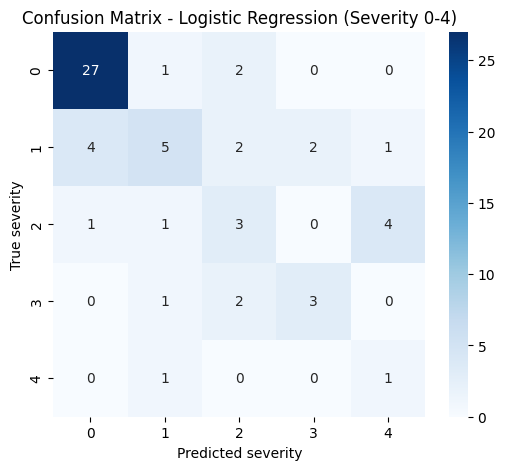

In [660]:
# Confusion matrix heatmap for Logistic Regression (severity 0-4)
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred2)
labels = [0, 1, 2, 3, 4]
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted severity')
plt.ylabel('True severity')
plt.title('Confusion Matrix - Logistic Regression (Severity 0-4)')
plt.show()

In [679]:
# code for RF
model3 = RandomForestClassifier(n_estimators=100)
model3.fit(X_train,y_train)

rounded_predictions3 = model3.predict(X_test)
predictions3 = model3.predict_proba(X_test)
y_pred3 = rounded_predictions3

import sklearn.metrics as metrics
scores3=metrics.accuracy_score(y_test,y_pred3)
print("Accuracy of RF = ",scores3)

print(metrics.confusion_matrix(y_test,y_pred3))
print(metrics.classification_report(y_test,y_pred3))


Accuracy of RF =  0.4918032786885246
[[29  0  1  0  0]
 [10  0  1  2  1]
 [ 2  3  1  1  2]
 [ 0  5  1  0  0]
 [ 1  0  0  1  0]]
              precision    recall  f1-score   support

           0       0.69      0.97      0.81        30
           1       0.00      0.00      0.00        14
           2       0.25      0.11      0.15         9
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         2

    accuracy                           0.49        61
   macro avg       0.19      0.22      0.19        61
weighted avg       0.38      0.49      0.42        61



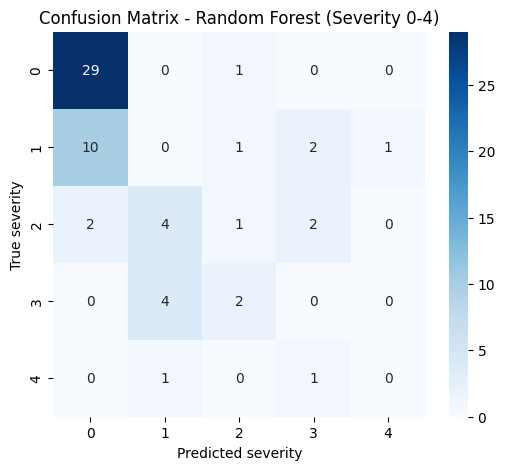

In [662]:
# Confusion matrix heatmap for Logistic Regression (severity 0-4)
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred3)
labels = [0, 1, 2, 3, 4]
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted severity')
plt.ylabel('True severity')
plt.title('Confusion Matrix - Random Forest (Severity 0-4)')
plt.show()

In [663]:
#weighted fusion
#same procedure for every model(1,2 and 3). for every model we need to take the prediction 
# values and then the values will be merged according to the procedure given in below.

p=1
#q=1-p
for i in range (19):
    p=p-.05
    q=1-p
    
    mixed=predictions2*p+predictions3*q
   

    out = []
    for i in range(len(y_test)):
        out.append(i)

    k=-1
    for i in range(len(y_test)):  
        k=k+1
        for j in range(5):
            max=numpy.max(mixed[i])
        
        for j in range(5):
            if (mixed[i][j]== max):
                out[k]=j
          

    import numpy as np
    out = np.asarray(out)   
    score3=metrics.accuracy_score(out,y_test)   
    print("  mixed  p  q","%.4f" %score3, "%.2f" %p,"%.2f" %q)

  mixed  p  q 0.6393 0.95 0.05
  mixed  p  q 0.6230 0.90 0.10
  mixed  p  q 0.5902 0.85 0.15
  mixed  p  q 0.5738 0.80 0.20
  mixed  p  q 0.5410 0.75 0.25
  mixed  p  q 0.5410 0.70 0.30
  mixed  p  q 0.5574 0.65 0.35
  mixed  p  q 0.5574 0.60 0.40
  mixed  p  q 0.5410 0.55 0.45
  mixed  p  q 0.5574 0.50 0.50
  mixed  p  q 0.5574 0.45 0.55
  mixed  p  q 0.5246 0.40 0.60
  mixed  p  q 0.5246 0.35 0.65
  mixed  p  q 0.5082 0.30 0.70
  mixed  p  q 0.5082 0.25 0.75
  mixed  p  q 0.4918 0.20 0.80
  mixed  p  q 0.4918 0.15 0.85
  mixed  p  q 0.4918 0.10 0.90
  mixed  p  q 0.4918 0.05 0.95


In [664]:
#after selecting the value of p and q which gives the highest accuracy.This value differs for different algorithms.
p=.55
q=1-p
mixed=predictions2*p+predictions3*q


out = []
for i in range(len(y_test)):
    out.append(i)

k=-1
#mixed
for i in range(len(y_test)):  
    k=k+1
    for j in range(5):
        max=numpy.max(mixed[i])
    for j in range(5):
        if (mixed[i][j]== max):
            out[k]=j

In [680]:
import numpy as np
out = np.asarray(out)
score3=metrics.accuracy_score(out,y_test)   
print("Accuracy of LR+RF",score3)




print(metrics.confusion_matrix(y_test,out))
print(metrics.classification_report(y_test,out))

Accuracy of LR+RF 0.5409836065573771
[[27  1  2  0  0]
 [10  0  0  3  1]
 [ 1  1  2  1  4]
 [ 0  1  2  3  0]
 [ 0  1  0  0  1]]
              precision    recall  f1-score   support

           0       0.71      0.90      0.79        30
           1       0.00      0.00      0.00        14
           2       0.33      0.22      0.27         9
           3       0.43      0.50      0.46         6
           4       0.17      0.50      0.25         2

    accuracy                           0.54        61
   macro avg       0.33      0.42      0.35        61
weighted avg       0.45      0.54      0.48        61



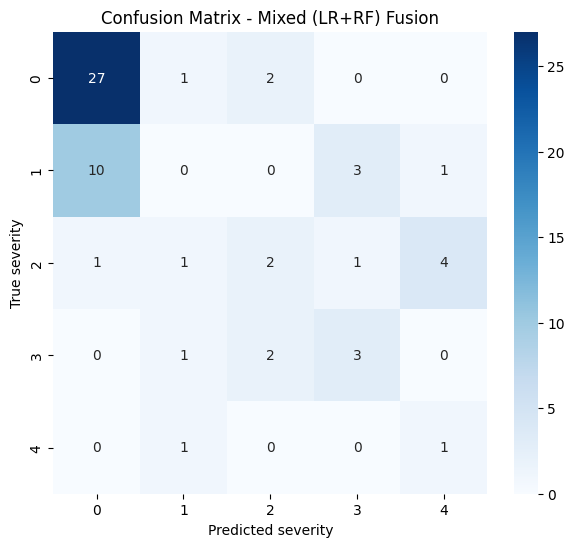

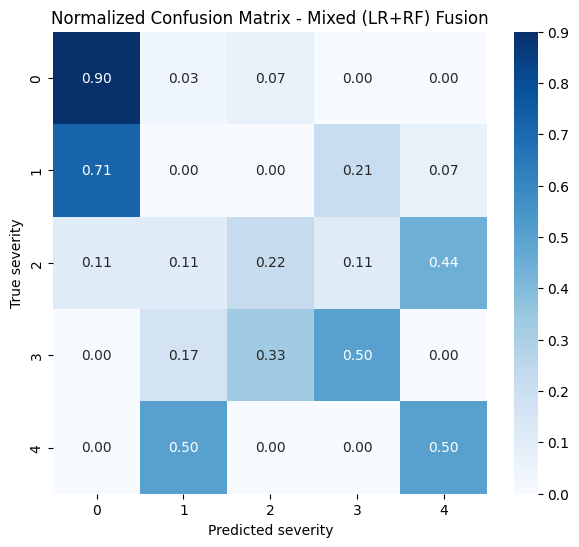

Classification Report - Mixed (LR+RF) Fusion:
              precision    recall  f1-score   support

           0       0.71      0.90      0.79        30
           1       0.00      0.00      0.00        14
           2       0.33      0.22      0.27         9
           3       0.43      0.50      0.46         6
           4       0.17      0.50      0.25         2

    accuracy                           0.54        61
   macro avg       0.33      0.42      0.35        61
weighted avg       0.45      0.54      0.48        61



In [666]:
# Confusion matrix and classification report for Mixed (LR+RF) fusion model
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Ensure 'out' and 'y_test' are available from previous cells
cm = confusion_matrix(y_test, out)
labels = [0, 1, 2, 3, 4]

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted severity')
plt.ylabel('True severity')
plt.title('Confusion Matrix - Mixed (LR+RF) Fusion')
plt.show()

# Normalized confusion matrix (rows = true classes)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(7,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted severity')
plt.ylabel('True severity')
plt.title('Normalized Confusion Matrix - Mixed (LR+RF) Fusion')
plt.show()

# Print classification report
print('Classification Report - Mixed (LR+RF) Fusion:')
print(classification_report(y_test, out))

In [667]:
macro_roc_auc_ovo = roc_auc_score(y_test, mixed, multi_class="ovo", average="macro")
weighted_roc_auc_ovo = roc_auc_score(y_test, mixed, multi_class="ovo", average="weighted")
macro_roc_auc_ovr = roc_auc_score(y_test, mixed, multi_class="ovr",average="macro")
weighted_roc_auc_ovr = roc_auc_score(y_test, mixed, multi_class="ovr",average="weighted")
#print all score for roc
print("macro_ovo,weight_ovo,macro_ovr,weight_ovr",
        macro_roc_auc_ovo, weighted_roc_auc_ovo,macro_roc_auc_ovr ,weighted_roc_auc_ovr)

macro_ovo,weight_ovo,macro_ovr,weight_ovr 0.7071428571428571 0.7820485297944314 0.786692688944239 0.8324486125588219


In [678]:
#ROC curve for LR

from sklearn.preprocessing import label_binarize
# Binarize the test labels for multiclass ROC
y_test_h = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
# Use predicted probabilities from Logistic Regression
y_score1 = predictions2  # shape: (n_samples, n_classes)
from sklearn.metrics import roc_curve, auc
from numpy import interp
from itertools import cycle
n_classes=5
lw=3
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_h[:, i], y_score1[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_h.ravel(), y_score1.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

In [669]:
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

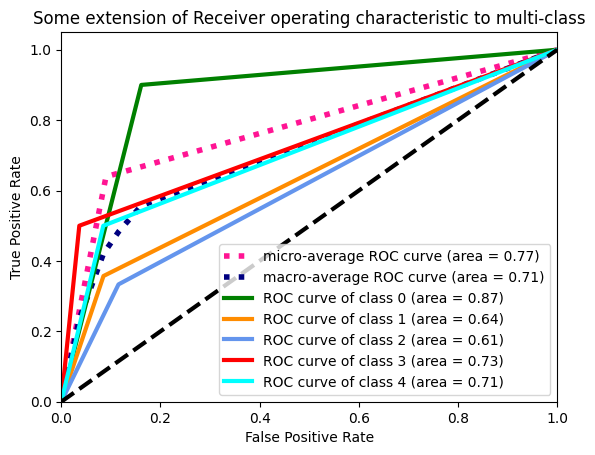

In [670]:
# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

colors = cycle(['green', 'darkorange', 'cornflowerblue','red','aqua'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()


In [672]:
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

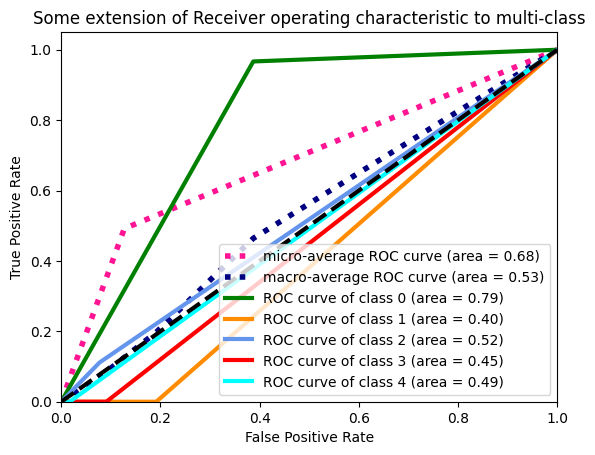

In [673]:
# Plot all ROC curves
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

colors = cycle(['green', 'darkorange', 'cornflowerblue','red','aqua'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()


In [674]:
#ROC curve for (LR+RF)


from sklearn.preprocessing import label_binarize
y_test_h = label_binarize(y_test, classes=[0, 1, 2, 3, 4])


y_score1 = label_binarize(out, classes=[0, 1, 2, 3, 4])
from sklearn.metrics import roc_curve, auc
from numpy import interp
from itertools import cycle
n_classes=5
lw=3
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_h[:, i], y_score1[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_h.ravel(), y_score1.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])


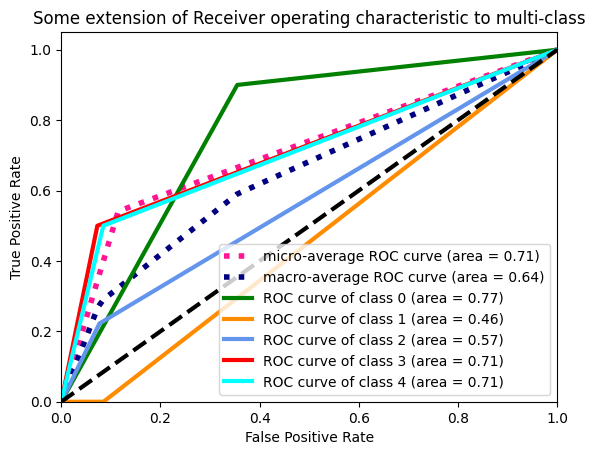

In [675]:
# Plot all ROC curves
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label='macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

colors = cycle(['green', 'darkorange', 'cornflowerblue','red','aqua'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()